In [2]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from os.path import join

config_dir = "../../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir, google_folder_id, download_dir
add_to_path(join(root_dir, 'src'))
import utils.visualization as visualisation
import utils.preprocessing as preprocessing
from data_loader import load_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Added to sys: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\Projet-recheche-INSA-anomaly-detection-librairy-1\src


In [3]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)

list_keys = list(data_dict.keys())


# Goal

The goal of this analyse is to use PCA and KPCA to detect the anomalous sessions. We will perform a global PCA on all sessions, then compare their distributions in PCA space. We can perform the clustering of the centroid, or use the Weisserstein distance. In general we will try to answer the following questions : 

- PCA and KPCA, which one is 'better' ? How to evaluate each approach ?
- How to compare the sessions ? 
    - PCA space or reconstruction
    - If PCA space, how to compare the sessions ? Centroid or distributions ?
    - Which method of clustering ?



In [4]:
import os

selected_sessions = {}
temp_list = []

for path, df in data_dict.items():
        # On extrait juste le nom du fichier
        clean_name = os.path.splitext(os.path.basename(path))[0]
        selected_sessions[clean_name] = df
        df_cleaned = preprocessing.clean_dataframe(df.copy())
        
        # C. Ajout de l'identifiant de session
        df_cleaned['session_id'] = clean_name
        
        # D. Stockage
        selected_sessions[clean_name] = df_cleaned
        temp_list.append(df_cleaned)


We concatenate all the sessions in one dataframe to help the analysis

In [5]:
df_all = pd.concat(temp_list, ignore_index=True)
display(df_all)

,datetime,nwl1,nwl2,nwl3,nwl4,fprd1,fprd2,fprd3,fprd4,pstr1,pstr3,astrw,g2,ny,vcrf,v2,time_real,session_id
0,2024-04-01 22:08:14.579,0.00,0.00,0.00,0.00,-3995.51,-4000.04,-6238.11,-6171.77,6.68066,6.82229,10.16580,-0.011067,0.087145,0.000,0.000000,0.00,T24S12-04_E-AL2706
1,2024-04-01 22:08:14.589,0.00,0.00,0.00,0.00,-3997.83,-3996.56,-6238.11,-6171.77,6.64945,6.82229,10.16580,0.000813,0.087145,0.000,0.000000,0.01,T24S12-04_E-AL2706
2,2024-04-01 22:08:14.599,0.00,0.00,0.00,0.00,-3993.19,-3995.40,-6236.48,-6171.77,6.72228,6.75729,10.16580,-0.011067,0.087145,0.000,0.000000,0.02,T24S12-04_E-AL2706
3,2024-04-01 22:08:14.609,0.00,0.00,0.00,0.00,-4000.15,-4002.36,-6236.48,-6171.77,6.61824,6.68147,10.16580,0.000813,0.087145,0.000,0.000000,0.03,T24S12-04_E-AL2706
4,2024-04-01 22:08:14.619,0.00,0.00,0.00,0.00,-3992.03,-3994.24,-6236.48,-6171.77,6.67026,6.84395,10.16580,-0.011067,0.007836,0.000,0.000000,0.04,T24S12-04_E-AL2706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612460,2024-04-09 16:37:55.315,1941.59,2048.39,2035.99,2000.11,3719.91,4061.02,8024.95,7322.66,6.99120,5.85707,1.76054,-0.191725,-0.735798,251.164,0.685691,95.15,T24S12-04_E-AL3690
612461,2024-04-09 16:37:55.325,1939.69,2054.29,2030.52,2005.31,4340.05,4175.77,7702.88,9025.20,4.76465,5.60793,1.59081,-0.132327,-0.735798,251.253,1.565400,95.16,T24S12-04_E-AL3690
612462,2024-04-09 16:37:55.335,1940.64,2060.19,2031.61,2001.15,4331.93,4648.70,8151.47,9155.63,6.62705,6.68032,1.37259,-0.251123,-0.815106,251.430,-2.204790,95.17,T24S12-04_E-AL3690
612463,2024-04-09 16:37:55.345,1942.54,2050.75,2039.26,2004.27,3632.97,4354.28,8744.66,9583.57,5.14961,3.60395,1.55040,-0.227364,-0.883085,251.518,-1.356500,95.18,T24S12-04_E-AL3690


# PCA

In [6]:
df_all.columns

Index(['datetime', 'nwl1', 'nwl2', 'nwl3', 'nwl4', 'fprd1', 'fprd2', 'fprd3',
       'fprd4', 'pstr1', 'pstr3', 'astrw', 'g2', 'ny', 'vcrf', 'v2',
       'time_real', 'session_id'],
      dtype='object')

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [8]:
# Standardize the data

cols = [c for c in df_all.columns if c not in ['datetime','session_id', 'index', 'time_real']]
dfpca = df_all.copy()
dfpca['session_id'] = dfpca['session_id'].astype("category")
scaler = StandardScaler()
df_center = scaler.fit_transform(dfpca[cols])

In [9]:
# Fit the data

pca = PCA()
respca = pca.fit_transform(df_center)

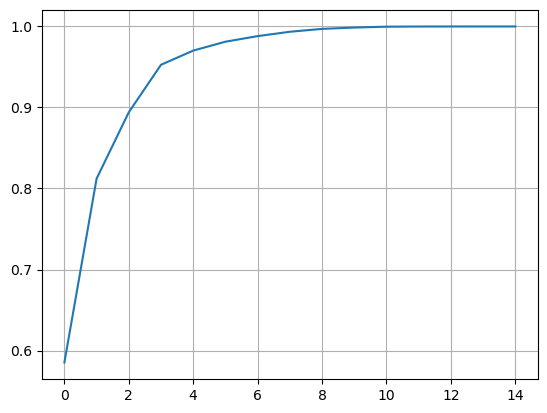

In [10]:
# Percentage of explained variance

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.grid()
plt.show()

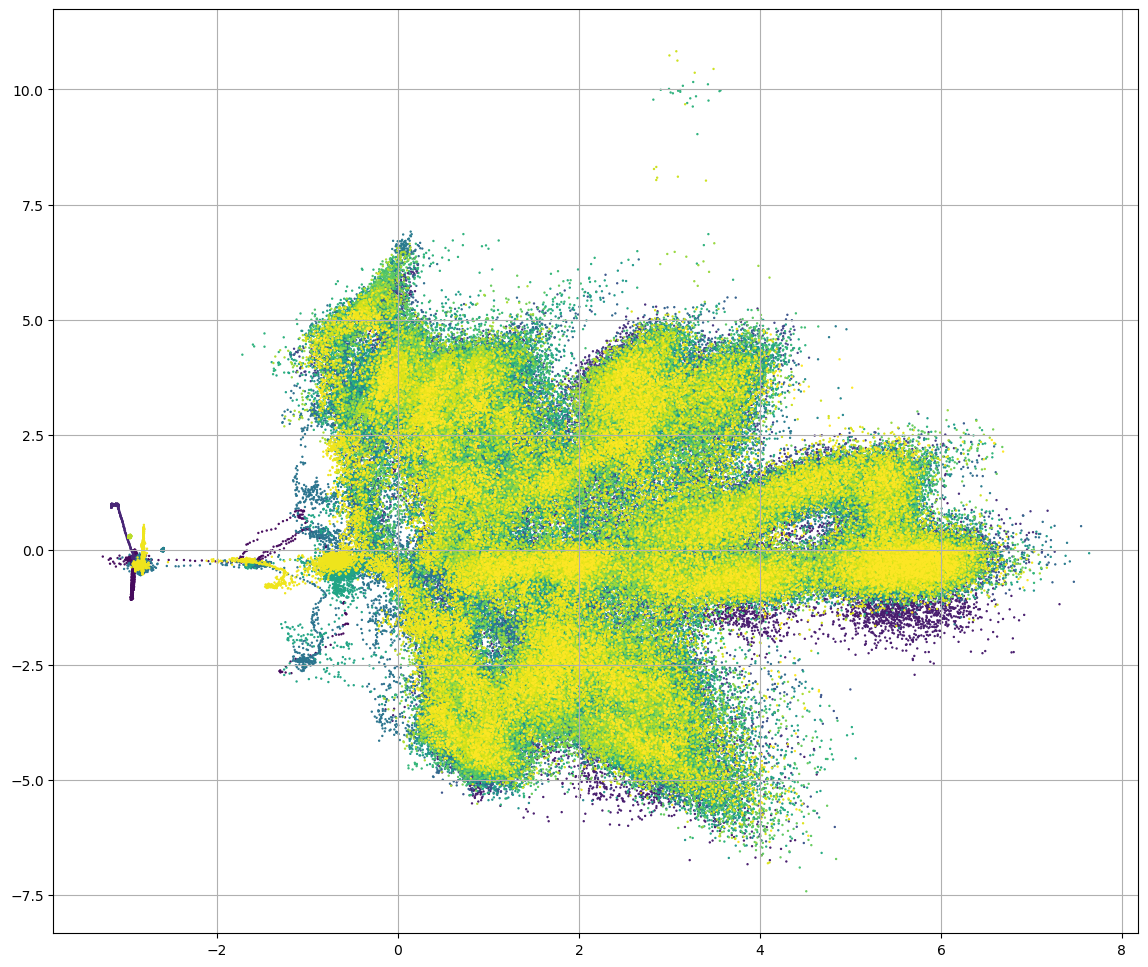

In [11]:
labels = pd.factorize(dfpca["session_id"].values)[0]
plt.figure(figsize=(14,12))
plt.scatter(respca[:,0], respca[:,1],s=0.5, c=labels)
plt.grid()
plt.show()

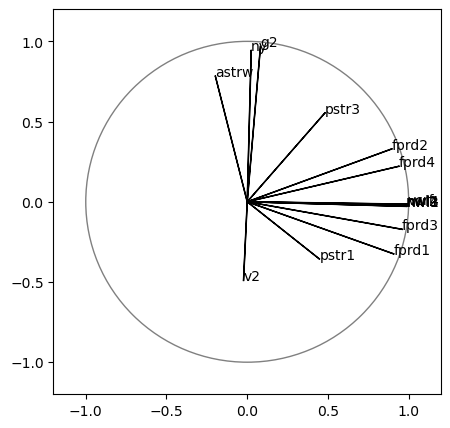

In [12]:
# Correlation circle : dim 1 and 2

coord1=pca.components_[0]*np.sqrt(pca.explained_variance_[0])
coord2=pca.components_[1]*np.sqrt(pca.explained_variance_[1])
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1, 1, 1)
for i, j, nom in zip(coord1,coord2, cols):
    plt.text(i, j, nom)
    plt.arrow(0,0,i,j,color='black')
plt.axis((-1.2,1.2,-1.2,1.2))
# cercle
c=plt.Circle((0,0), radius=1, color='gray', fill=False)
ax.add_patch(c)
plt.show()

The correlation circle is usefull when we want to detect the source of anomalies. Supposing that we know a session i is anomalous via the analysis in PCA space, we can guess which sensors have problems based on the differences on each dimension comparing to other normal sessions.

## Analysis in PCA space

Now we will detect the sessions having anomalies in PCA space, using clustering methods. Before that we need to define the "distance" between 2 samples. A naive approach is to compare the sessions using the centroid, and the distance can be euclidean distance or mahalanobis distance. A better but more complicated approach is to use [Wasserstein distance](https://en.wikipedia.org/wiki/Wasserstein_metric) which is used to calculate the distance between 2 distributions on a given metric space.

### Centroid

In [13]:
df = pd.DataFrame({
    "PC1": respca[:,0],
    "PC2": respca[:,1],
    "session": dfpca["session_id"].values
})
centroid_pca = df.groupby("session")[["PC1","PC2"]].mean()
display(centroid_pca)

C:\Users\fauli\AppData\Local\Temp\ipykernel_11216\360268250.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centroid_pca = df.groupby("session")[["PC1","PC2"]].mean()


,PC1,PC2
session,,
T24S12-04_E-AL2706,-2.895030,-0.149187
T24S12-04_E-AL2725,-2.702940,-0.413091
T24S12-04_E-AL2761,-2.931143,-0.320749
T24S12-04_E-AL2780,2.568499,-0.521124
T24S12-04_E-AL2819,-2.929226,-0.005540
T24S12-04_E-AL2870,2.601231,0.219357
T24S12-04_E-AL2889,2.547996,0.185511
T24S12-04_E-AL2909,2.502762,0.179134
T24S12-04_E-AL2928,2.630750,0.182966


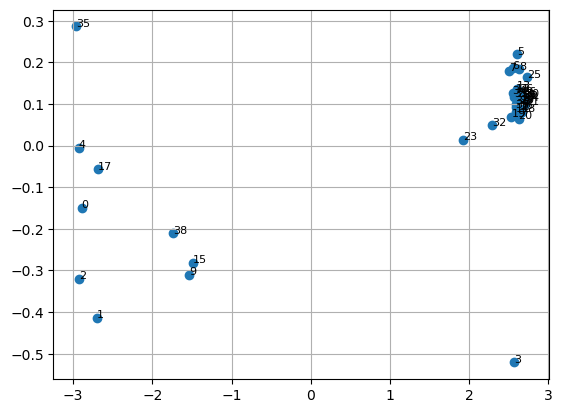

In [14]:
plt.scatter(centroid_pca["PC1"],centroid_pca["PC2"])
for i, (idx, row) in enumerate(centroid_pca.iterrows()):
    plt.text(row["PC1"], row["PC2"], i, fontsize=8)
plt.grid()
plt.show()

In order to cluster the centroid, we will use the Agglomerative clustering which support other metric than euclidean.

#### Euclidean distance

C:\Users\fauli\AppData\Local\Temp\ipykernel_11216\3241639832.py:12: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  cah1= sch.linkage(D1, method='complete')


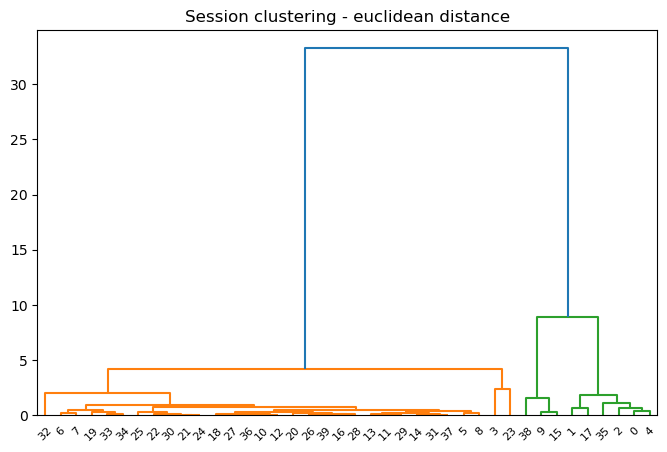

In [15]:
# CAH with euclidean distance

import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform, pdist

# Suppose D is your session x session distance DataFrame
session_names = centroid_pca.index.values
# Convert to condensed distance vector
D1 = squareform(pdist(centroid_pca.values, metric="euclidean"))

# Hierarchical clustering
cah1= sch.linkage(D1, method='complete')

plt.figure(figsize=(8,5))
sch.dendrogram(cah1)
plt.title("Session clustering - euclidean distance")
plt.show()

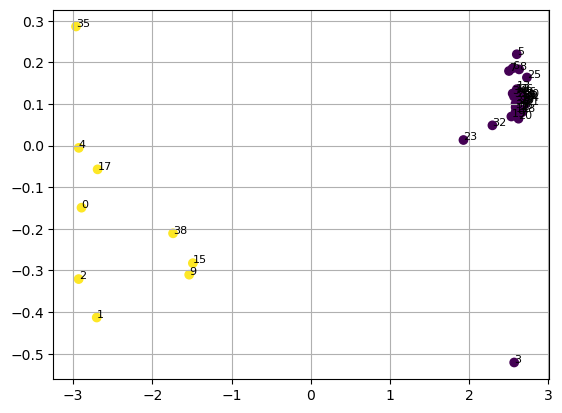

In [16]:
k = 2
labels1 = sch.fcluster(cah1, t=k, criterion="maxclust")  # cluster id for each session

# sessions per cluster
clusters1 = {}
for s, c in zip(session_names, labels1):
    clusters1.setdefault(c, []).append(s)

cluster_map1 = dict(zip(session_names, labels1))
df["cluster"] = df["session"].map(cluster_map1)

plt.scatter(centroid_pca["PC1"],centroid_pca["PC2"], c=labels1)

for i, (idx, row) in enumerate(centroid_pca.iterrows()):
    plt.text(row["PC1"], row["PC2"], i, fontsize=8)

plt.grid()
plt.show()

#### Mahalanobis distance

C:\Users\fauli\AppData\Local\Temp\ipykernel_11216\2379029578.py:6: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  cah2= sch.linkage(D2, method='complete')


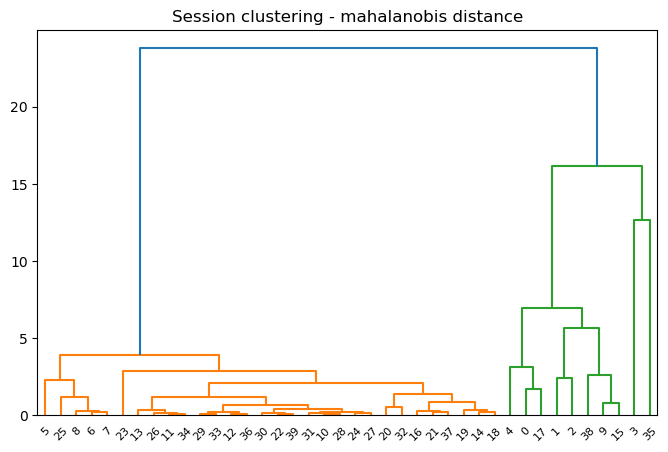

In [17]:
# Mahalanobis distance

D2 = squareform(pdist(centroid_pca.values, metric="mahalanobis"))

# Hierarchical clustering
cah2= sch.linkage(D2, method='complete')

plt.figure(figsize=(8,5))
sch.dendrogram(cah2)
plt.title("Session clustering - mahalanobis distance")
plt.show()

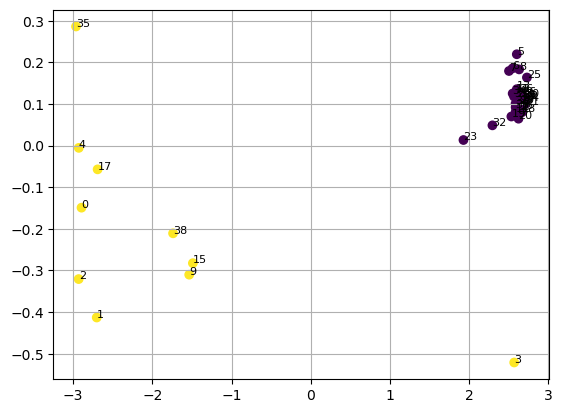

In [18]:
k = 2
labels2 = sch.fcluster(cah2, t=k, criterion="maxclust")  # cluster id for each session

# sessions per cluster
clusters2 = {}
for s, c in zip(session_names, labels2):
    clusters2.setdefault(c, []).append(s)

cluster_map2 = dict(zip(session_names, labels2))
df["cluster2"] = df["session"].map(cluster_map2)
plt.scatter(centroid_pca["PC1"],centroid_pca["PC2"], c=labels2)

for i, (idx, row) in enumerate(centroid_pca.iterrows()):
    plt.text(row["PC1"], row["PC2"], i, fontsize=8)

plt.grid()
plt.show()

**Comment:** The larger group on the upper right seems to be normal sessions, while the other are anomalous. The final result of the 2 distances is almost the same, except for the 3rd session having the centroid on the lower right of the graph. We will now analyze this session.

In [19]:
# Find the different point

error_id = session_names[3]
error_id

'T24S12-04_E-AL2780'

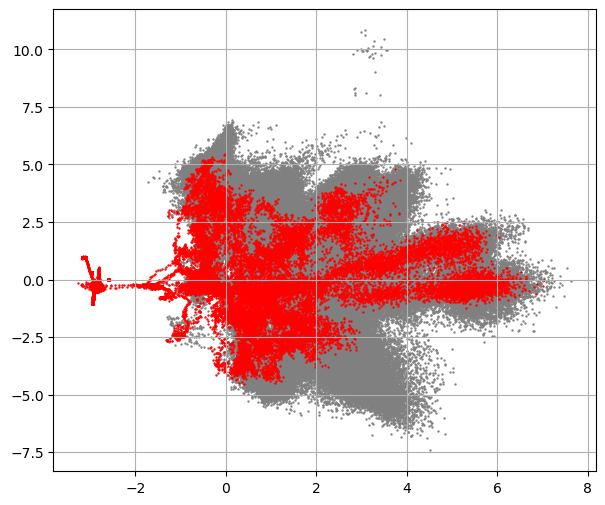

In [20]:
# PCA space, colored by cluster of CAH-euclidean

plt.figure(figsize=(7,6))
plt.scatter(df[df['cluster']==1].values[:,0], df[df['cluster']==1].values[:,1],s=0.5, c='gray') #Normal cluster
plt.scatter(df[df['cluster']==2].values[:,0], df[df['cluster']==2].values[:,1],s=0.5, c='red') #Anomaly cluster
plt.grid()
plt.show()

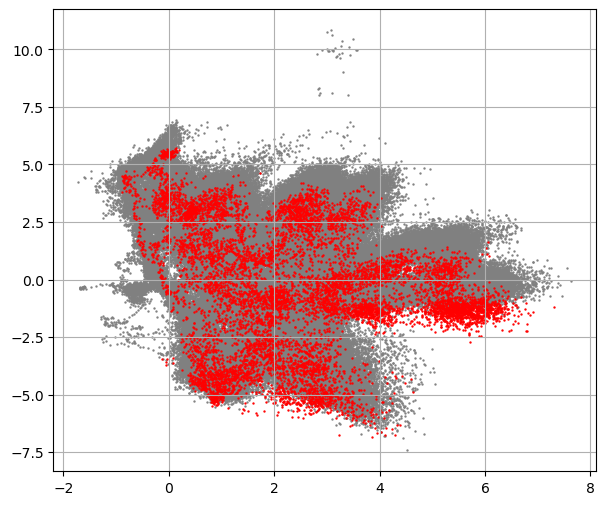

In [21]:
# projection of the 3rd session on PCA space

plt.figure(figsize=(7,6))
plt.scatter(df[df['cluster2']==1].values[:,0], df[df['cluster2']==1].values[:,1],s=0.5, c='gray') #Normal cluster
plt.scatter(df[df["session"] == error_id].values[:,0], df[df["session"] == error_id].values[:,1],s=0.5, c='red')
plt.grid()
plt.show()

**Comments:** We know that the centroid of this session have the 1st coordinate like the cloud point, while the 2e coordinate is much lower. Hence we can deduce that the source of anomalies are related to the sensors which are highly correlated to dim2. Those variables are ny, g2, astrw, v2.

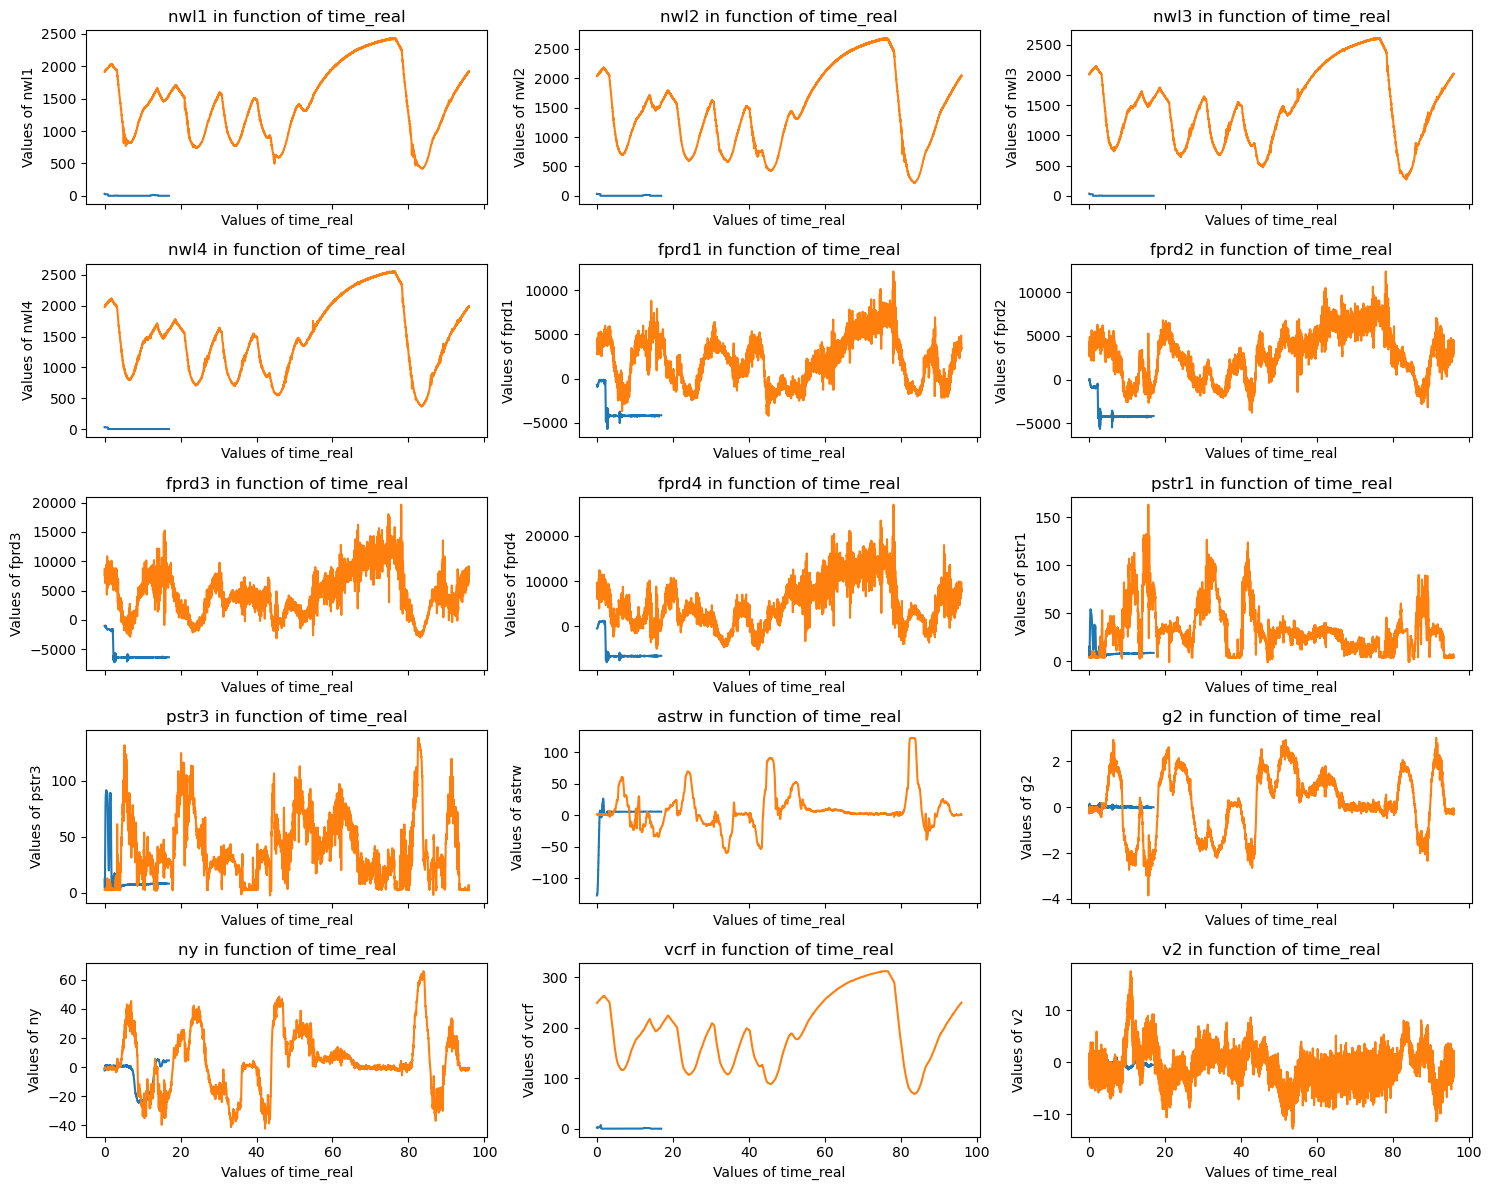

In [23]:
# Plot of variables highly correlated to dim 2 of the 3rd session and a normal session

#id of a session in cluster 1, i.e normal session
norm_id = clusters2[1][0]
error_id = session_names[1]

df_error = df_all[df_all["session_id"] == error_id]
df_norm = df_all[df_all["session_id"] == norm_id]

#list_cols = ["astrw", "ny", "g2", "v2"]
nrows, ncols = 5,3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
axes = axes.flatten()
for ax, col in zip(axes, cols):
    visualisation.plot(df_error, 'time_real', col, ax=ax)
    visualisation.plot(df_norm, 'time_real', col, ax=ax)
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

**Comments:** For this session the value of v2 sensor is higher than a normal sessions

#### Remark

We've done the Agglomerative clustering in the PCA space for the centroids of the sessions. However the result is not completely reliable. In fact, the "distance" in the graph doesn't have any sense, since the graph is plotted in euclidean metric. Moreover 2 centroids close together doesn't indicate that 2 sessions are close or having the same properties. In order to have a better guarantee, we should consider the whole distribution of each session, not only its centroid.

### Distribution - Wasserstein distance

Now we will use the Wasserstein distance to calculate the distance between the distribution of point. Note that the calculation is really heavy since the dataset has many points, so we will downsample the data before the calculation. For this section we need to install the package POT.

In [25]:
import ot

dist_matrix_pca = pd.DataFrame(index=session_names, columns=session_names)

for i in range(len(session_names)):
    for j  in range(i,len(session_names)): #the distance is symmetric, so we only need to calculate upper/lower half of the matrix

        X = np.asarray(df[df['session']==session_names[i]].values[:,:2],dtype="float")[::50] #Down sample the data
        Y = np.asarray(df[df['session']==session_names[j]].values[:,:2],dtype="float")[::50]
        n, m = len(X), len(Y)

        # uniform weights (each point has equal mass)
        a = np.ones(n) / n
        b = np.ones(m) / m

        # cost matrix: squared Euclidean distances between points
        M = ot.dist(X, Y, metric='euclidean')**2

        # EMD cost (W2^2 if you use squared cost)
        dist_matrix_pca.iloc[i,j] = np.sqrt(ot.emd2(a, b, M,numThreads="max"))
        dist_matrix_pca.iloc[j,i] = dist_matrix_pca.iloc[i,j]

<Axes: >

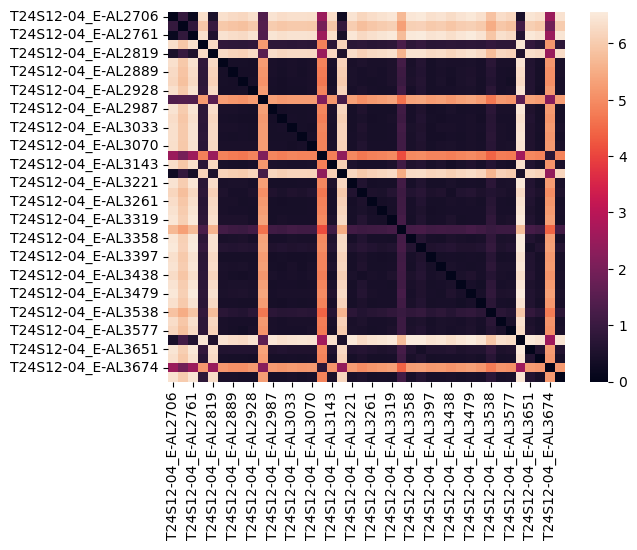

In [26]:
# Distance matrix

import seaborn as sns
sns.heatmap(dist_matrix_pca.astype(float))

To visualize the sessions with this distance, we can use [multidimensional scaling](https://scikit-learn.org/stable/auto_examples/manifold/plot_mds.html), a method to reconstruct the 2d coordinates from a distance matrix.

C:\Users\LT-MSI\.conda\envs\PI\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
C:\Users\LT-MSI\.conda\envs\PI\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


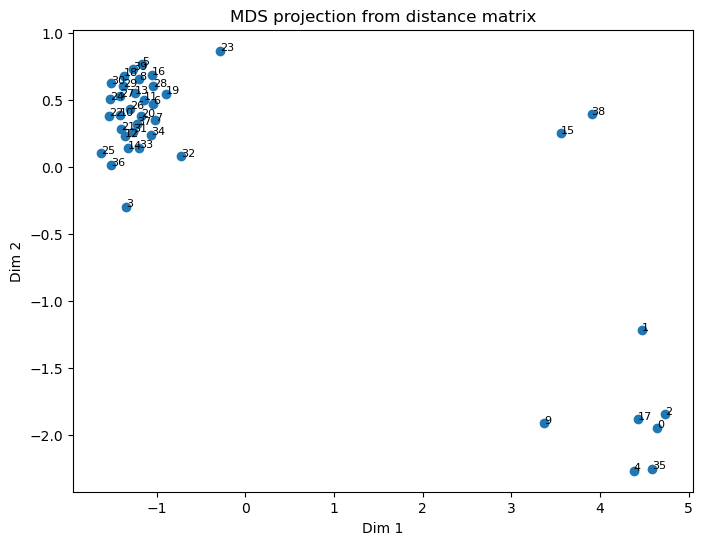

In [27]:
from sklearn.manifold import MDS

mds = MDS(
    n_components=2,
    metric="precomputed",
    random_state=0
)

coords = mds.fit_transform(dist_matrix_pca)

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1])

for i, name in enumerate(session_names):
    plt.text(coords[i, 0], coords[i, 1], str(i), fontsize=8)

plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("MDS projection from distance matrix")
plt.show()

**Comments:** There are 3 groups of points, a large group on the upper left, the small group in the lower right, and 15th and 38th sessions. We can expect that the large group is the normal sessions, the smaller is the anomalous, and for 15th and 38th sessions we might need a further analysis.

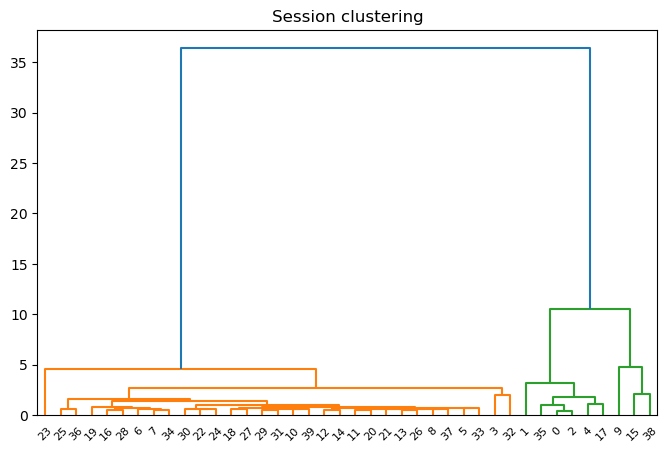

In [28]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# D = distance matrix (numpy array)
cah_pca = sch.linkage(dist_matrix_pca, method='complete')

plt.figure(figsize=(8,5))
sch.dendrogram(cah_pca)
plt.title("Session clustering")
plt.show()

In [29]:
k = 2
labels_pca = sch.fcluster(cah_pca, t=k, criterion="maxclust")  # cluster id for each session

# sessions per cluster
clusters_pca = {}
for s, c in zip(session_names, labels_pca):
    clusters_pca.setdefault(c, []).append(s)

cluster_map_pca = dict(zip(session_names, labels_pca))
df["cluster_d"] = df["session"].map(cluster_map_pca)
clusters_pca

{np.int32(2): ['T24S12-04_E-AL2706',
  'T24S12-04_E-AL2725',
  'T24S12-04_E-AL2761',
  'T24S12-04_E-AL2819',
  'T24S12-04_E-AL2948',
  'T24S12-04_E-AL3089',
  'T24S12-04_E-AL3155',
  'T24S12-04_E-AL3597',
  'T24S12-04_E-AL3674'],
 np.int32(1): ['T24S12-04_E-AL2780',
  'T24S12-04_E-AL2870',
  'T24S12-04_E-AL2889',
  'T24S12-04_E-AL2909',
  'T24S12-04_E-AL2928',
  'T24S12-04_E-AL2987',
  'T24S12-04_E-AL3014',
  'T24S12-04_E-AL3033',
  'T24S12-04_E-AL3052',
  'T24S12-04_E-AL3070',
  'T24S12-04_E-AL3143',
  'T24S12-04_E-AL3221',
  'T24S12-04_E-AL3240',
  'T24S12-04_E-AL3261',
  'T24S12-04_E-AL3280',
  'T24S12-04_E-AL3319',
  'T24S12-04_E-AL3339',
  'T24S12-04_E-AL3358',
  'T24S12-04_E-AL3377',
  'T24S12-04_E-AL3397',
  'T24S12-04_E-AL3417',
  'T24S12-04_E-AL3438',
  'T24S12-04_E-AL3458',
  'T24S12-04_E-AL3479',
  'T24S12-04_E-AL3499',
  'T24S12-04_E-AL3538',
  'T24S12-04_E-AL3558',
  'T24S12-04_E-AL3577',
  'T24S12-04_E-AL3651',
  'T24S12-04_E-AL3671',
  'T24S12-04_E-AL3690']}

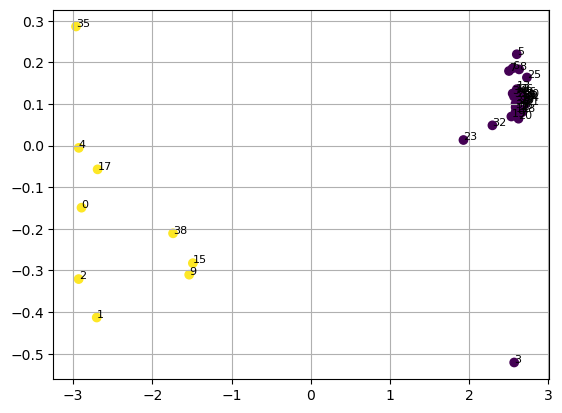

In [30]:
plt.scatter(centroid_pca["PC1"],centroid_pca["PC2"], c=labels_pca)

for i, (idx, row) in enumerate(centroid_pca.iterrows()):
    plt.text(row["PC1"], row["PC2"], i, fontsize=8)

plt.grid()
plt.show()

**Comment:** 

We can detect the same anomalous sessions as using only the centroid. For the 3rd session that we analyzed before, the distribution of v2 is almost the same as other normal sessions, except for having the slightly reduced amplitude. As a result, its distribution is still close enough to other normal sessions, and it is then classified in the same cluster as other. However this method is more reliable since it compares the whole distribution of the sessions, which is better if we want to have a deeper analysis

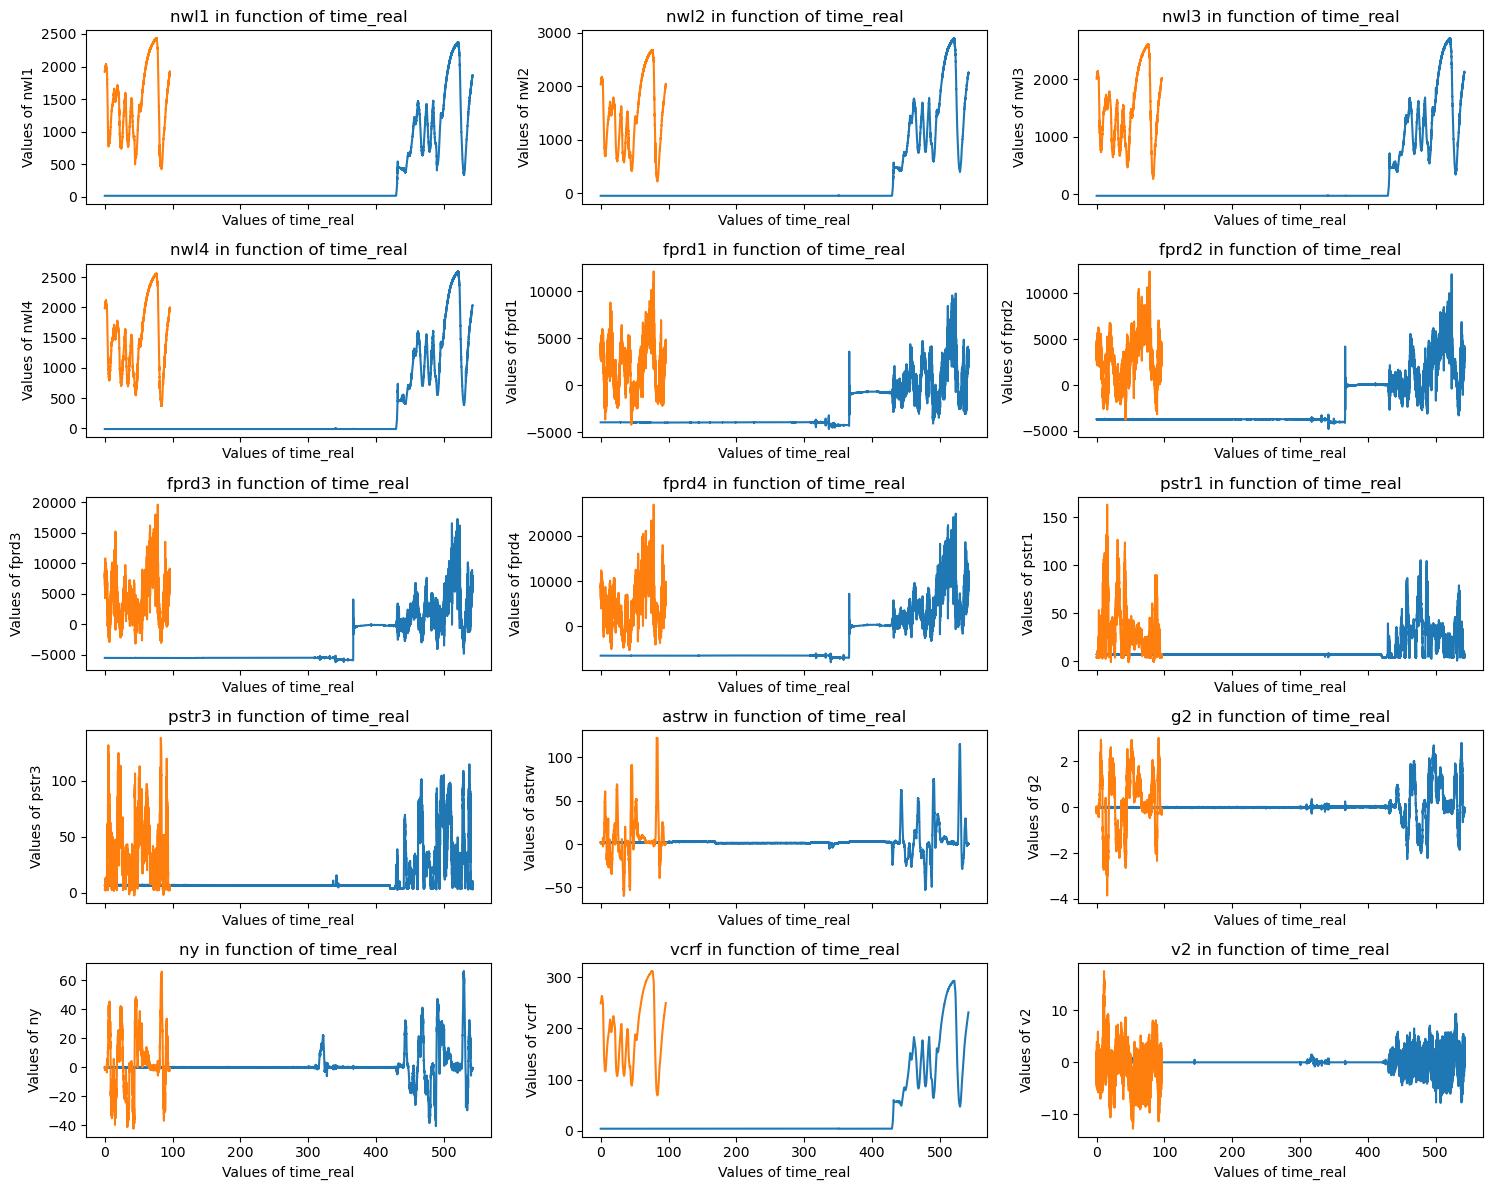

In [31]:
# Visualize the 38th session (or 15th session)

norm_id = clusters2[1][0]
error_id = session_names[38]
#error_id = session_names[15]

df_error = df_all[df_all["session_id"] == error_id]
df_norm = df_all[df_all["session_id"] == norm_id]

#list_cols = ["astrw", "ny", "g2", "v2"]
nrows, ncols = 5,3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
axes = axes.flatten()
for ax, col in zip(axes, cols):
    visualisation.plot(df_error, 'time_real', col, ax=ax)
    visualisation.plot(df_norm, 'time_real', col, ax=ax)
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

**Comments:** The 15th and 38th sessions are close in Wasserstein distance and show the situation where sensors had been turned on before the run. Thus we can't conclude anything yet, and we need methods to either remove the constant period, or synchronize the data.

In [32]:
# list of anomalous sessions, to compare with the anl01p2 data_exploration

clusters2[2]

['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']

## Further analysis

In this section we will analyze the sessions in the cluster 1. Be careful with the index of session, since the list of session considered has been changed.

In [33]:
# List of sessions that we will analyze

list_sessions = clusters2[1]
centroid_pca2 = centroid_pca.loc[list_sessions]

In [34]:
# euclidean

De = squareform(pdist(centroid_pca2.values, metric="euclidean")) #euclidean
Dm = squareform(pdist(centroid_pca2.values, metric="mahalanobis")) #mahalanobis

idx = np.where(np.isin(session_names, list_sessions))[0]
Dw = np.asanyarray(dist_matrix_pca,dtype="float")[np.ix_(idx, idx)] #Wasserstein

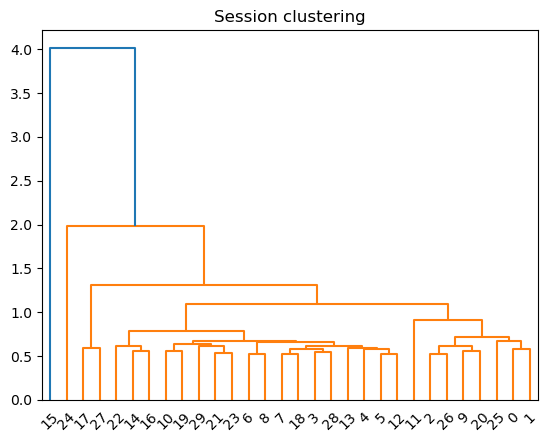

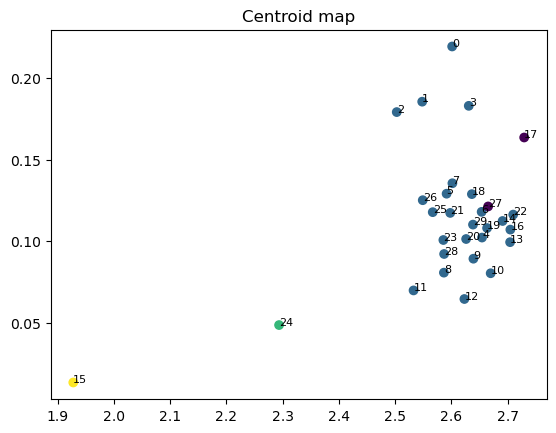

C:\Users\LT-MSI\.conda\envs\PI\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
C:\Users\LT-MSI\.conda\envs\PI\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


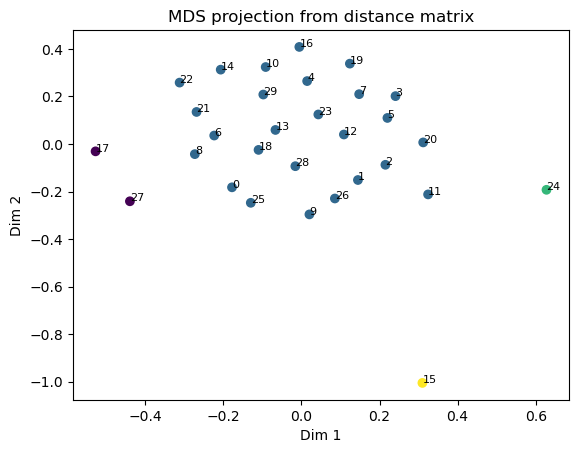

In [35]:
D = Dw
cah = sch.linkage(D, method='complete')
sch.dendrogram(cah)
plt.title("Session clustering")
plt.show()

k = 4
labels = sch.fcluster(cah, t=k, criterion="maxclust")  # cluster id for each session

# sessions per cluster
clusters = {}
for s, c in zip(list_sessions, labels):
    clusters.setdefault(c, []).append(s)

#Centroid
plt.scatter(centroid_pca2["PC1"], centroid_pca2["PC2"],c=labels)
for i, (idx, row) in enumerate(centroid_pca2.iterrows()):
    plt.text(row["PC1"], row["PC2"], i, fontsize=8)
plt.title("Centroid map")
plt.show()

#MDS
coords = mds.fit_transform(Dw)
plt.scatter(coords[:, 0], coords[:, 1], c=labels)
for i, name in enumerate(list_sessions):
    plt.text(coords[i, 0], coords[i, 1], str(i), fontsize=8)
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("MDS projection from distance matrix")
plt.show()

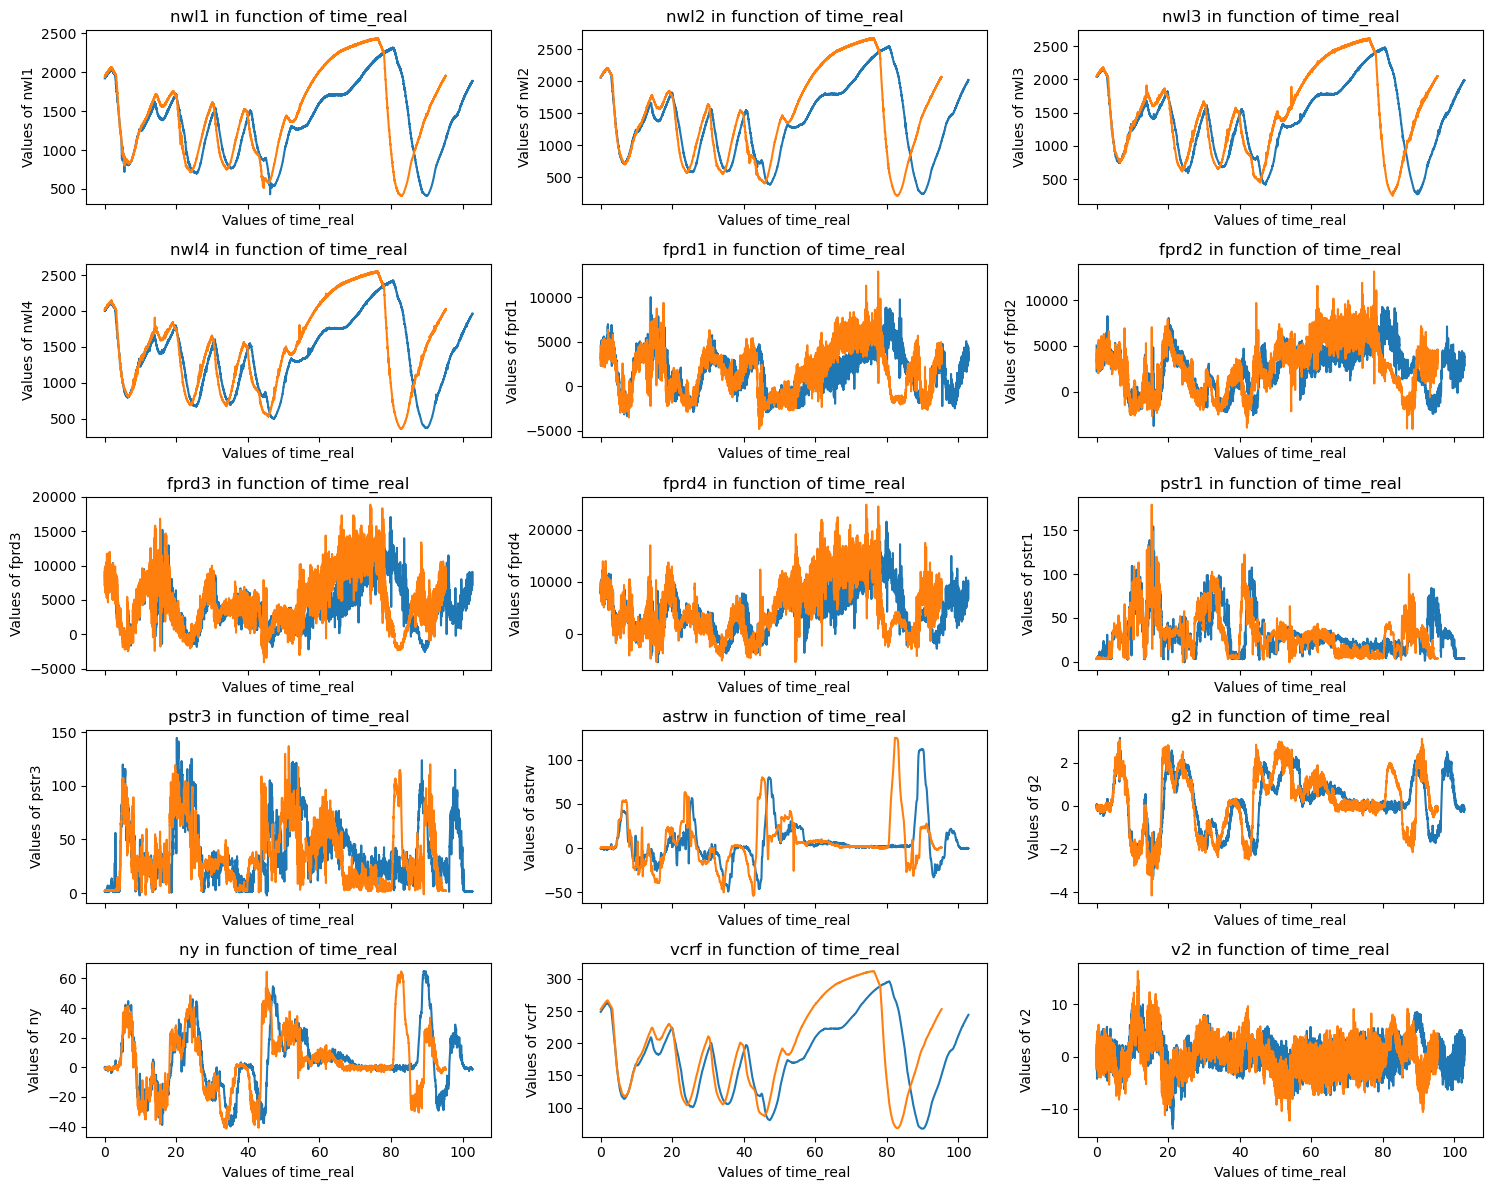

In [36]:
df_error = df_all[df_all["session_id"] == list_sessions[24]]
df_norm = df_all[df_all["session_id"] == list_sessions[23]]

#list_cols = ["astrw", "ny", "g2", "v2"]
nrows, ncols = 5,3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
axes = axes.flatten()
for ax, col in zip(axes, cols):
    visualisation.plot(df_error, 'time_real', col, ax=ax)
    visualisation.plot(df_norm, 'time_real', col, ax=ax)
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

**Comments:** In this case we can not conclude if the sensors are anomalous or physically correct. We need to find a way to synchronize the signals.

### Remark

- The clustering using centroid might give a good result, but not always and we don't have any guarantee. The fact that 1st and 2nd principal components correspond to huge amount of explained variance only gives us a higher probability of having good result. 
- The analysis on Wasserstein metric is more reliable but more limited in terms of calculation. However, a session may have the distribution close to a normal session, but not necessarily correct. An example is the session T24S12-04_E-AL2780 (session_name[3]).
- The synchronization of the data might be useful.
- Several methods to improve the results :
    - Do PCA for 3, 4 principal components
    - Combine with other methods : remove constant period, ...
    - Try other clustering method, with different parameters. The Agglomerative clustering works naturally with different metrics, but we can still try other methods

# KPCA

KPCA is a popular nonlinear dimension reduction method, but the storage and computational problems make it impratical to use for large dataset. This method requires $O(n^2)$ for storage and $O(n^3)$ for computing, with n the total number of observations of the dataset. To deal with this, we need to find a better approximation of KPCA. There are two potential approches : Multiple Greedy KPCA (choosing m "best" observations) and Nystroem (chossing m random observations).

## Multiple Greedy kernel PCA (MGKPCA)

[MGKPCA](https://ieeexplore-ieee-org.gorgone.univ-toulouse.fr/document/4020700) is a method combining Incremental KPCA and Greedy KPCA to adapt to huge dataset. Greedy KPCA is basically to choose m observations (among n, with m << n) of the dataset such that the projection of Xm is representative enough comparing to X. The Incremental KPCA is to divide the dataset to blocks, then performing KPCA on each block. The method MGKPCA proposed by Chin et al. combines this 2 methods to have a fast but efficient replacement for traditional KPCA.

In [84]:
from anomaly_detection.dimension_reduction.kpca import MultiGKPCA

Before begin, we will compare the result of traditional KPCA and MGKPCA on a smaller dataset.

Time :  2.6369667053222656


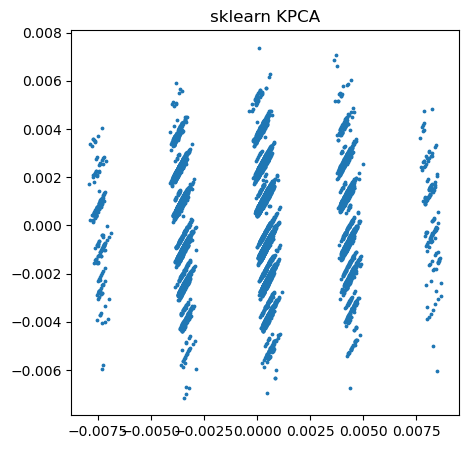

In [88]:
# Reference : traditional KPCA

from sklearn.decomposition import KernelPCA
import matplotlib.pyplot as plt
import numpy as np
import time

X = df_center.copy()
Xs = X[50000:60000]

kpca_ref = KernelPCA(n_components=2, kernel="rbf", gamma=0.05)
start = time.time()
Z_ref = kpca_ref.fit_transform(Xs)
end = time.time()
print("Time : ", end - start)

plt.figure(figsize=(5,5))
plt.scatter(Z_ref[:,0], Z_ref[:,1], s=3)
plt.title("sklearn KPCA")
plt.show()

Time :  0.09697151184082031


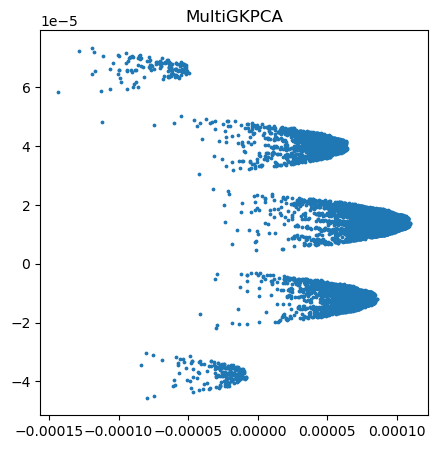

In [89]:
# MGKPCA

mgkpca_small = MultiGKPCA(
    n_blocks=20,
    kernel="rbf",
    gamma=0.05,
    max_subset_per_block=20,
    mse_tol=1e-3,
    block_var_keep=0.999,
    global_var_keep=0.9999,
    max_block_kpcs=8,
    max_global_kpcs=10,
    shuffle = True,
    verbose=False
)

start = time.time()
Z_test = mgkpca_small.fit_transform(Xs, n_components=2)
end = time.time()
print("Time : ", end - start)

plt.figure(figsize=(5,5))
plt.scatter(Z_test[:,0], Z_test[:,1], s=3)
plt.title("MultiGKPCA")
plt.show()

In [94]:
# Comparing the correlation using Pearson
from scipy.spatial.distance import pdist
from scipy.stats import pearsonr

D_ref = pdist(Z_ref[:, :2])
D_mg  = pdist(Z_test[:, :2])

print("distance correlation:", pearsonr(D_ref, D_mg)[0])

distance correlation: 0.6611709764545631


In [95]:
# Performing MGKPCA

import time

X = df_center
mgkpca = MultiGKPCA(
    n_blocks=60,
    kernel="rbf",
    gamma=0.05,
    max_subset_per_block=30,
    mse_tol=1e-2,
    block_var_keep=0.99,
    global_var_keep=0.99,
    max_block_kpcs = 8,
    max_global_kpcs=10,
    shuffle=True,
    random_state=42,
    verbose=False #Set to true to see the result of each iteration
)
start = time.time()
mgkpca.fit(X)
end = time.time()
print("Global library size:", mgkpca.library_size_)
print("Global #KPCs:", mgkpca.n_kpcs_)
print("Time: ", end - start)

Global library size: 1800
Global #KPCs: 10
Time:  104.34098958969116


In [96]:
# Check the quality of kernel. The diag should be one, and the off diag should be around 0.1 - 0.5, 
# not too high (gamma too small) but not too low (gamma too high).
from sklearn.metrics.pairwise import rbf_kernel

idx = np.random.choice(len(X), 2000, replace=False)
Xs = X[idx]

K = rbf_kernel(Xs, gamma=mgkpca.gamma)

print("diag mean:", np.mean(np.diag(K)))
print("off diag mean:", np.mean(K - np.eye(len(K))))
print("off diag std:", np.std(K - np.eye(len(K))))

diag mean: 1.0
off diag mean: 0.40131523747414666
off diag std: 0.3480648258515497


In [97]:
# Tranform the data to MGKPCA space. The dataset is huge, so we use the transformation in batches

Z = mgkpca.transform_batches(X, n_components=10) 

Transforming batch 0:10000 / 612465
Transforming batch 10000:20000 / 612465
Transforming batch 20000:30000 / 612465
Transforming batch 30000:40000 / 612465
Transforming batch 40000:50000 / 612465
Transforming batch 50000:60000 / 612465
Transforming batch 60000:70000 / 612465
Transforming batch 70000:80000 / 612465
Transforming batch 80000:90000 / 612465
Transforming batch 90000:100000 / 612465
Transforming batch 100000:110000 / 612465
Transforming batch 110000:120000 / 612465
Transforming batch 120000:130000 / 612465
Transforming batch 130000:140000 / 612465
Transforming batch 140000:150000 / 612465
Transforming batch 150000:160000 / 612465
Transforming batch 160000:170000 / 612465
Transforming batch 170000:180000 / 612465
Transforming batch 180000:190000 / 612465
Transforming batch 190000:200000 / 612465
Transforming batch 200000:210000 / 612465
Transforming batch 210000:220000 / 612465
Transforming batch 220000:230000 / 612465
Transforming batch 230000:240000 / 612465
Transforming ba

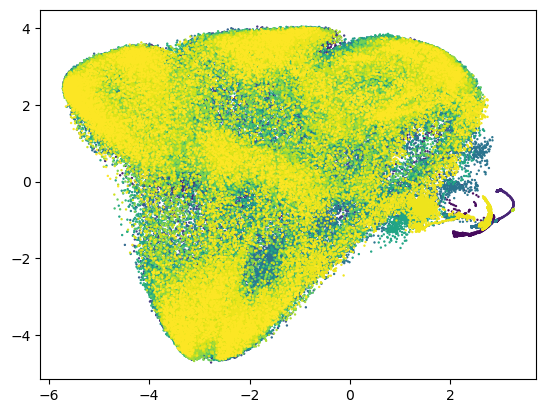

In [98]:
labels = pd.factorize(dfpca["session_id"].values)[0]
plt.scatter(Z[:,0], Z[:,1], s = 0.5, c=labels)
plt.show()

In [102]:
# Creating dataset containing the centroid of each session

df_kpca = pd.DataFrame({
    "PC1": Z[:,0],
    "PC2": Z[:,1],
    "PC3": Z[:,2],
    "PC4": Z[:,3],
    "session": dfpca["session_id"].values
})
centroid_kpca = df_kpca.groupby("session")[df_kpca.iloc[:,:-1].columns].mean()
display(centroid_kpca)

,PC1,PC2,PC3,PC4
session,,,,
T24S12-04_E-AL2706,2.936269,-1.019558,-2.104519,0.490815
T24S12-04_E-AL2725,2.429964,-1.052607,-1.738439,0.214990
T24S12-04_E-AL2761,2.700740,-1.093501,-2.059860,0.313394
T24S12-04_E-AL2780,-2.006486,0.243792,2.305217,0.651454
T24S12-04_E-AL2819,2.863024,-0.906914,-1.882324,0.623934
T24S12-04_E-AL2870,-2.440655,0.902429,1.342721,-0.686164
T24S12-04_E-AL2889,-2.408795,0.837633,1.326746,-0.652802
T24S12-04_E-AL2909,-2.328149,0.818121,1.358339,-0.544246
T24S12-04_E-AL2928,-2.460246,0.861726,1.330104,-0.599906


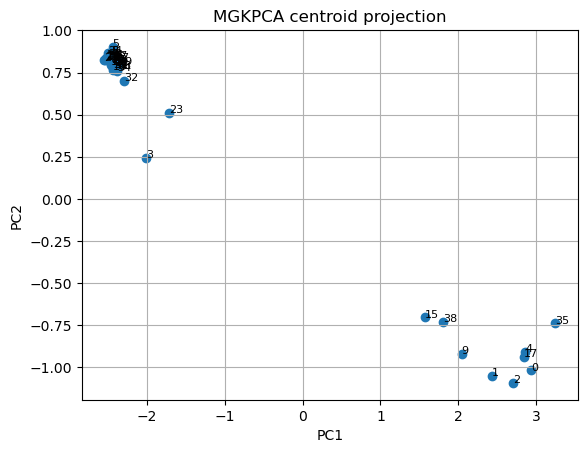

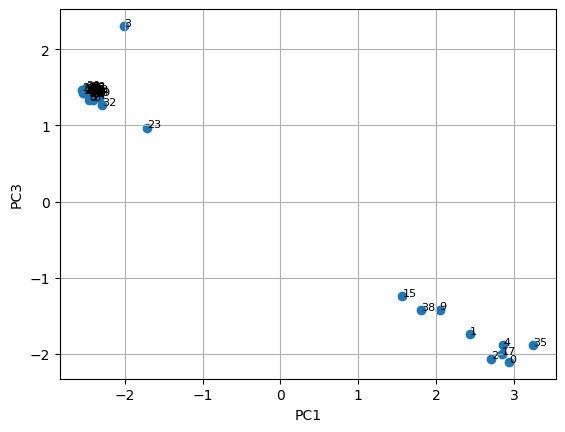

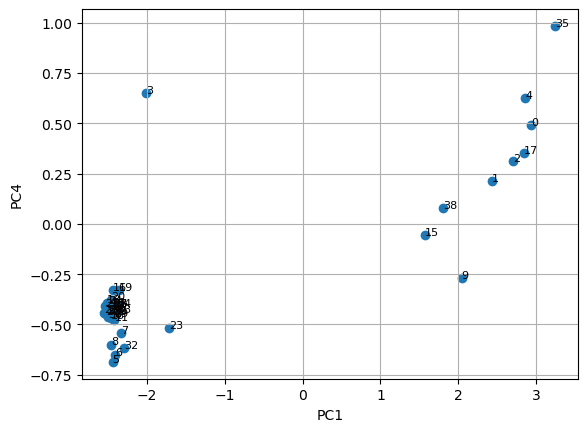

In [105]:
# Plot the centroids in MGKPCA space

plt.scatter(centroid_kpca["PC1"],centroid_kpca["PC2"])

for i, (idx, row) in enumerate(centroid_kpca.iterrows()):
    plt.text(row["PC1"], row["PC2"], i, fontsize=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("MGKPCA centroid projection")
plt.grid()
plt.show()

plt.scatter(centroid_kpca["PC1"],centroid_kpca["PC3"])

for i, (idx, row) in enumerate(centroid_kpca.iterrows()):
    plt.text(row["PC1"], row["PC3"], i, fontsize=8)
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.grid()
plt.show()

plt.scatter(centroid_kpca["PC1"],centroid_kpca["PC4"])

for i, (idx, row) in enumerate(centroid_kpca.iterrows()):
    plt.text(row["PC1"], row["PC4"], i, fontsize=8)
plt.xlabel("PC1")
plt.ylabel("PC4")
plt.grid()
plt.show()

C:\Users\LT-MSI\AppData\Local\Temp\ipykernel_27924\984842908.py:10: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  cahK= sch.linkage(Dk, method='complete')


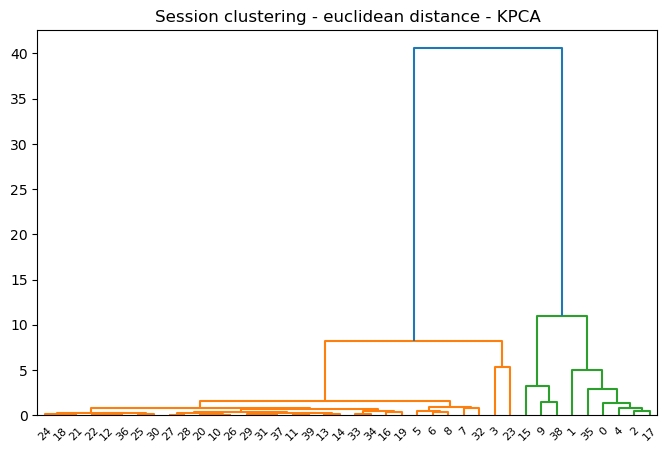

In [106]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform, pdist

# Suppose D is your session x session distance DataFrame
session_names = centroid_kpca.index.values
# Convert to condensed distance vector
Dk = squareform(pdist(centroid_kpca.values, metric="euclidean"))

# Hierarchical clustering
cahK= sch.linkage(Dk, method='complete')

plt.figure(figsize=(8,5))
sch.dendrogram(cahK)
plt.title("Session clustering - euclidean distance - KPCA")
plt.show()

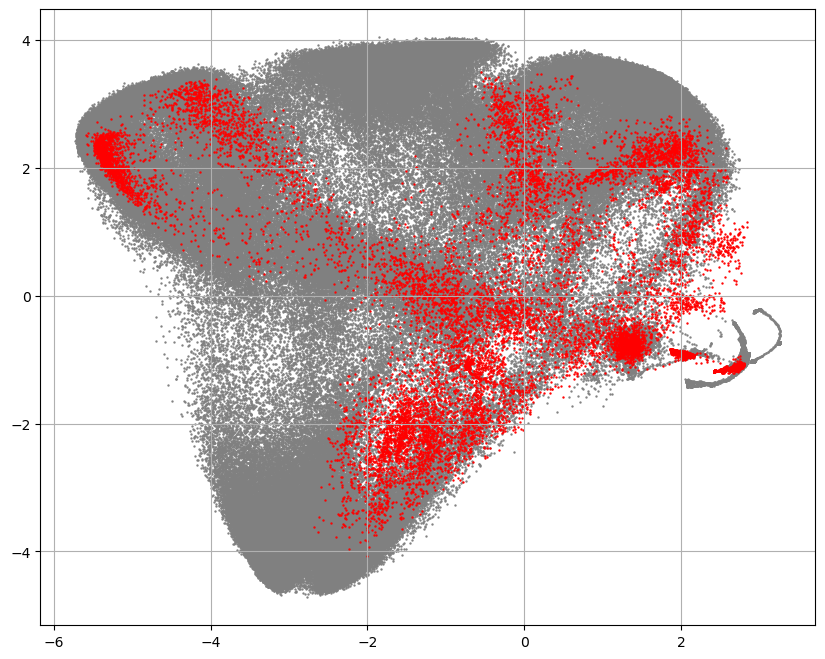

In [152]:
# Plot the projection of i-th session on MGKPCA space

index = 15

plt.figure(figsize=(10,8))
plt.scatter(df_kpca[df_kpca['session']!=session_names[index]].values[:,0], df_kpca[df_kpca['session']!=session_names[index]].values[:,1],s=0.5, c='gray')
plt.scatter(df_kpca[df_kpca['session']==session_names[index]].values[:,0], df_kpca[df_kpca['session']==session_names[index]].values[:,1],s=0.5, c='red')
plt.grid()
plt.show()

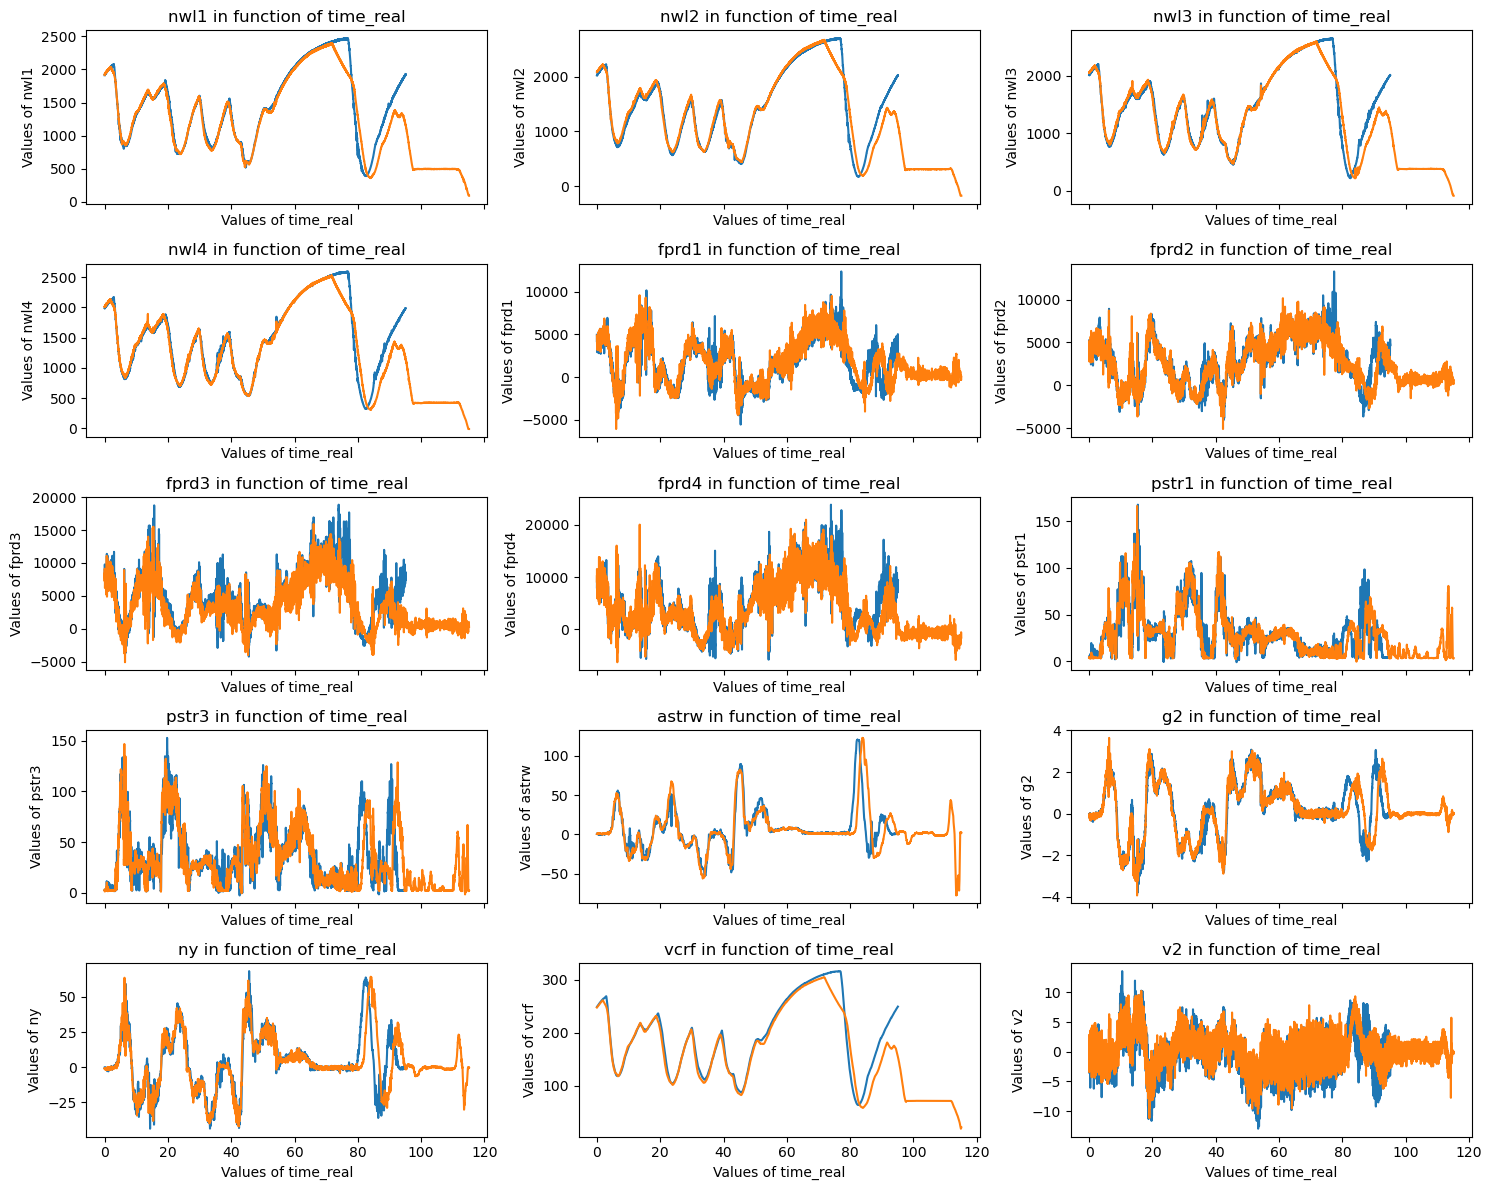

In [60]:
# Plot normal session vs anomalous session

norm_id = session_names[8]
error_id = session_names[23]
df_error = df_all[df_all["session_id"] == error_id]
df_norm = df_all[df_all["session_id"] == norm_id]

#list_cols = ["astrw", "ny", "g2", "v2"]
nrows, ncols = 5,3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
axes = axes.flatten()
for ax, col in zip(axes, cols):
    visualisation.plot(df_norm, 'time_real', col, ax=ax)
    visualisation.plot(df_error, 'time_real', col, ax=ax)
    
for ax in axes[len(cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## Nystroem

This [method](https://scikit-learn.org/stable/modules/generated/sklearn.kernel_approximation.Nystroem.html) chooses m random observations to estimate the matrix K, then apply the PCA.

In [127]:
from sklearn.kernel_approximation import Nystroem
feature_map_nystroem = Nystroem(gamma=.05,
                                random_state=42,
                                n_components=1800, n_jobs=-1) # n_components is the number of observations we will use, here we set it to 1800 like in MGKPCA
kpcaN = PCA(n_components = 4)
start = time.time()
Zn = kpcaN.fit_transform(feature_map_nystroem.fit_transform(X))
end = time.time()
print("Time : ", end - start)

Time :  48.299126625061035


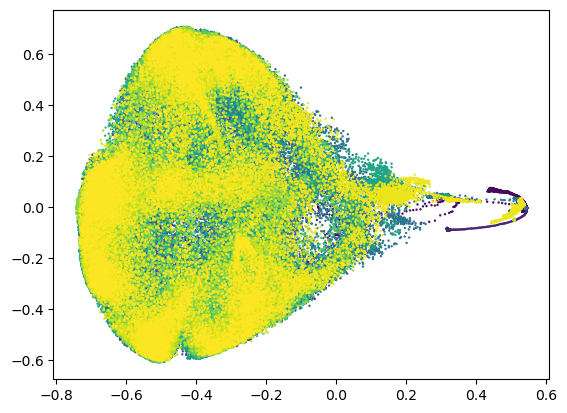

In [128]:
labels = pd.factorize(dfpca["session_id"].values)[0]
plt.scatter(Zn[:,0],Zn[:,1], c = labels, s = 0.5)
plt.show()

In [129]:
df_kpcaN = pd.DataFrame({
    "PC1": Zn[:,0],
    "PC2": Zn[:,1],
    "PC3": Zn[:,2],
    "PC4": Zn[:,3],
    "session": dfpca["session_id"].values
})
centroid_kpcaN = df_kpcaN.groupby("session")[df_kpcaN.iloc[:,:-1].columns].mean()
display(centroid_kpcaN)

,PC1,PC2,PC3,PC4
session,,,,
T24S12-04_E-AL2706,0.543301,-0.004901,0.061139,-0.032167
T24S12-04_E-AL2725,0.458153,0.018963,0.031337,-0.026965
T24S12-04_E-AL2761,0.535900,0.012413,0.063900,-0.027105
T24S12-04_E-AL2780,-0.417162,0.053037,-0.098077,-0.064585
T24S12-04_E-AL2819,0.501107,-0.013114,0.050983,-0.061201
T24S12-04_E-AL2870,-0.473814,-0.013321,-0.042751,-0.004725
T24S12-04_E-AL2889,-0.472492,-0.003787,-0.045411,0.013596
T24S12-04_E-AL2909,-0.466581,-0.000553,-0.047244,0.014836
T24S12-04_E-AL2928,-0.472456,-0.005541,-0.034503,-0.005438


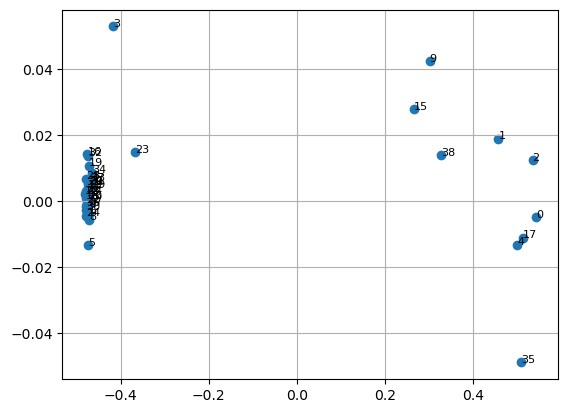

In [130]:
plt.scatter(centroid_kpcaN["PC1"],centroid_kpcaN["PC2"])

for i, (idx, row) in enumerate(centroid_kpcaN.iterrows()):
    plt.text(row["PC1"], row["PC2"], i, fontsize=8)

plt.grid()
plt.show()

C:\Users\LT-MSI\AppData\Local\Temp\ipykernel_27924\1710622239.py:8: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  cahKN= sch.linkage(DkN, method='complete')


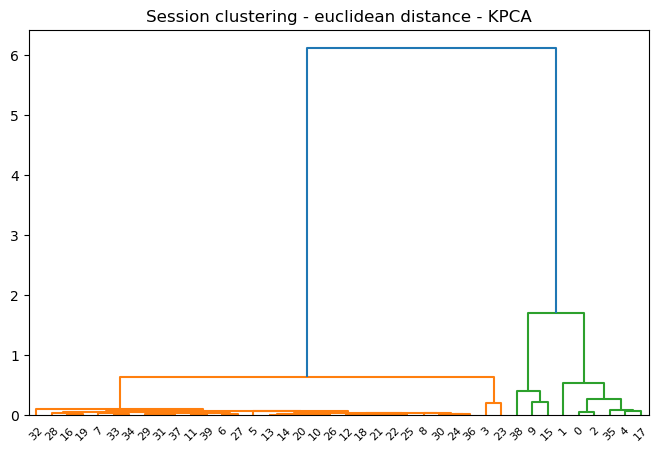

In [131]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform, pdist

# Convert to condensed distance vector
DkN = squareform(pdist(centroid_kpcaN.values[:,:3], metric="euclidean"))

# Hierarchical clustering
cahKN= sch.linkage(DkN, method='complete')

plt.figure(figsize=(8,5))
sch.dendrogram(cahKN)
plt.title("Session clustering - euclidean distance - KPCA")
plt.show()

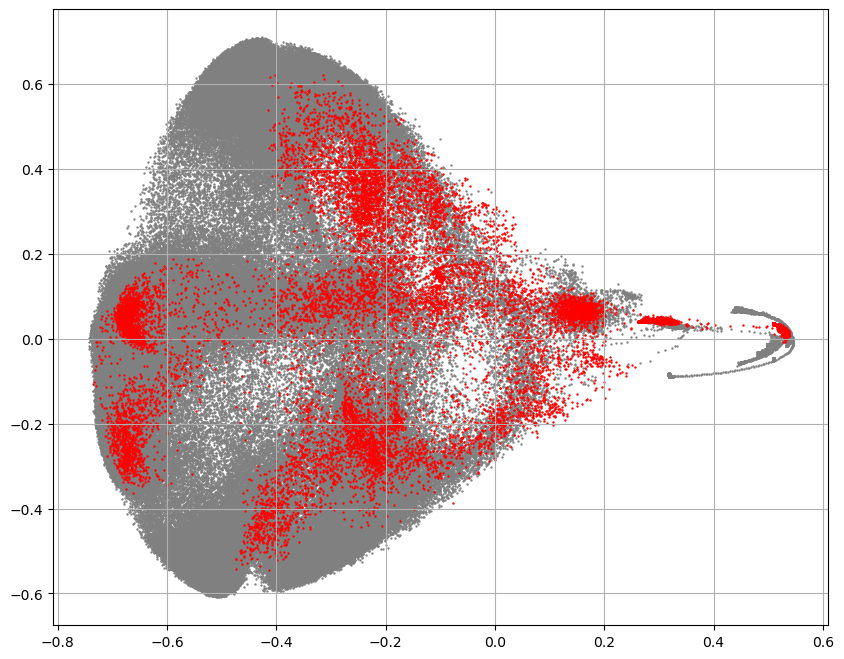

In [151]:
index = 15

plt.figure(figsize=(10,8))
plt.scatter(df_kpcaN[df_kpcaN['session']!=session_names[index]].values[:,0], df_kpcaN[df_kpcaN['session']!=session_names[index]].values[:,1],s=0.5, c='gray')
plt.scatter(df_kpcaN[df_kpcaN['session']==session_names[index]].values[:,0], df_kpcaN[df_kpcaN['session']==session_names[index]].values[:,1],s=0.5, c='red')
plt.grid()
plt.show()

## Remark

- The execution time of both methods is acceptable, and Nystroem shows a faster execution time.
- For both method, we obtain similar results as PCA. In terms of execution time, PCA is definitely better, but to conclude whether PCA or KPCA is better, a deeper analysis should be performed.

# On the second data set

In [4]:
%load_ext autoreload
%autoreload 2

config_dir = "../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir,google_folder_id, google_folder_id2, download_dir
add_to_path(join(root_dir, 'src'))
from data_loader import load_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Already in sys: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\Projet-recheche-INSA-anomaly-detection-librairy-1\src


In [12]:
data_dict2, extracted_dir = load_data(
    file_id=google_folder_id2,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data2.tar",
    pattern="*.csv",
)
print(len(data_dict2), "CSV files loaded")
first_key = next(iter(data_dict2))
print("Example file:", first_key)
print(data_dict2[first_key].head())

list_keys2 = list(data_dict2.keys())
list_session2 = []
df_list = []
for s in list_keys2:
    df = data_dict2[s].copy()
    df_clean = preprocessing.clean_dataframe(df)
    if df_clean.shape[0] != 0:
        list_session2.append(s)
        df_clean['session_id'] = s 
        df_list.append(df_clean)

Extracted data found at: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24
Loading CAST data from: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24
64 CSV files loaded
Example file: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24\T24S15-04_E-AL10009.csv
                  datetime     nwl1     nwl2     nwl3     nwl4    fprd1  \
0  2024-05-27T06:27:25.884  1758.07  1819.07  1818.91  1804.18  1716.18   
1  2024-05-27T06:27:25.894  1756.17  1824.98  1820.00  1810.42  1689.52   
2  2024-05-27T06:27:25.904  1767.57  1822.61  1815.63  1798.98  1657.06   
3  2024-05-27T06:27:25.914  1765.67  1822.61  1816.72  1801.06  1800.80   
4 

In [9]:
import joblib


# 1. On charge le fichier
model_pca = joblib.load('models/pca_model.joblib')

# 2. On affiche son type exact pour savoir comment l'utiliser
print(f"Type du modèle chargé : {type(model_pca)}")

Type du modèle chargé : <class 'sklearn.decomposition._pca.PCA'>


c:\Users\fauli\anaconda3\envs\projet_recherche\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [13]:
df_all2 = pd.concat(df_list, ignore_index=True)

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist, squareform



## PCA

In [15]:
cols = [c for c in df_all2.columns if c not in ['datetime', 'session_id', 'index', 'time_real']]

scaler2 = StandardScaler()
df_center2 = scaler2.fit_transform(df_all2[cols])

pca2 = PCA()
respca2 = pca2.fit_transform(df_center2)

In [16]:
df_pca = pd.DataFrame({
    "PC1": respca2[:, 0],
    "PC2": respca2[:, 1],
    "session": df_all2["session_id"].values
})

## Clustering

In [18]:
centroid_pca = df_pca.groupby("session")[["PC1", "PC2"]].mean()
session_names = centroid_pca.index.values

D1 = squareform(pdist(centroid_pca.values, metric="euclidean"))
cah = sch.linkage(D1, method='complete')

C:\Users\fauli\AppData\Local\Temp\ipykernel_2756\2823928306.py:5: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  cah = sch.linkage(D1, method='complete')


C:\Users\fauli\AppData\Local\Temp\ipykernel_2756\2622472359.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


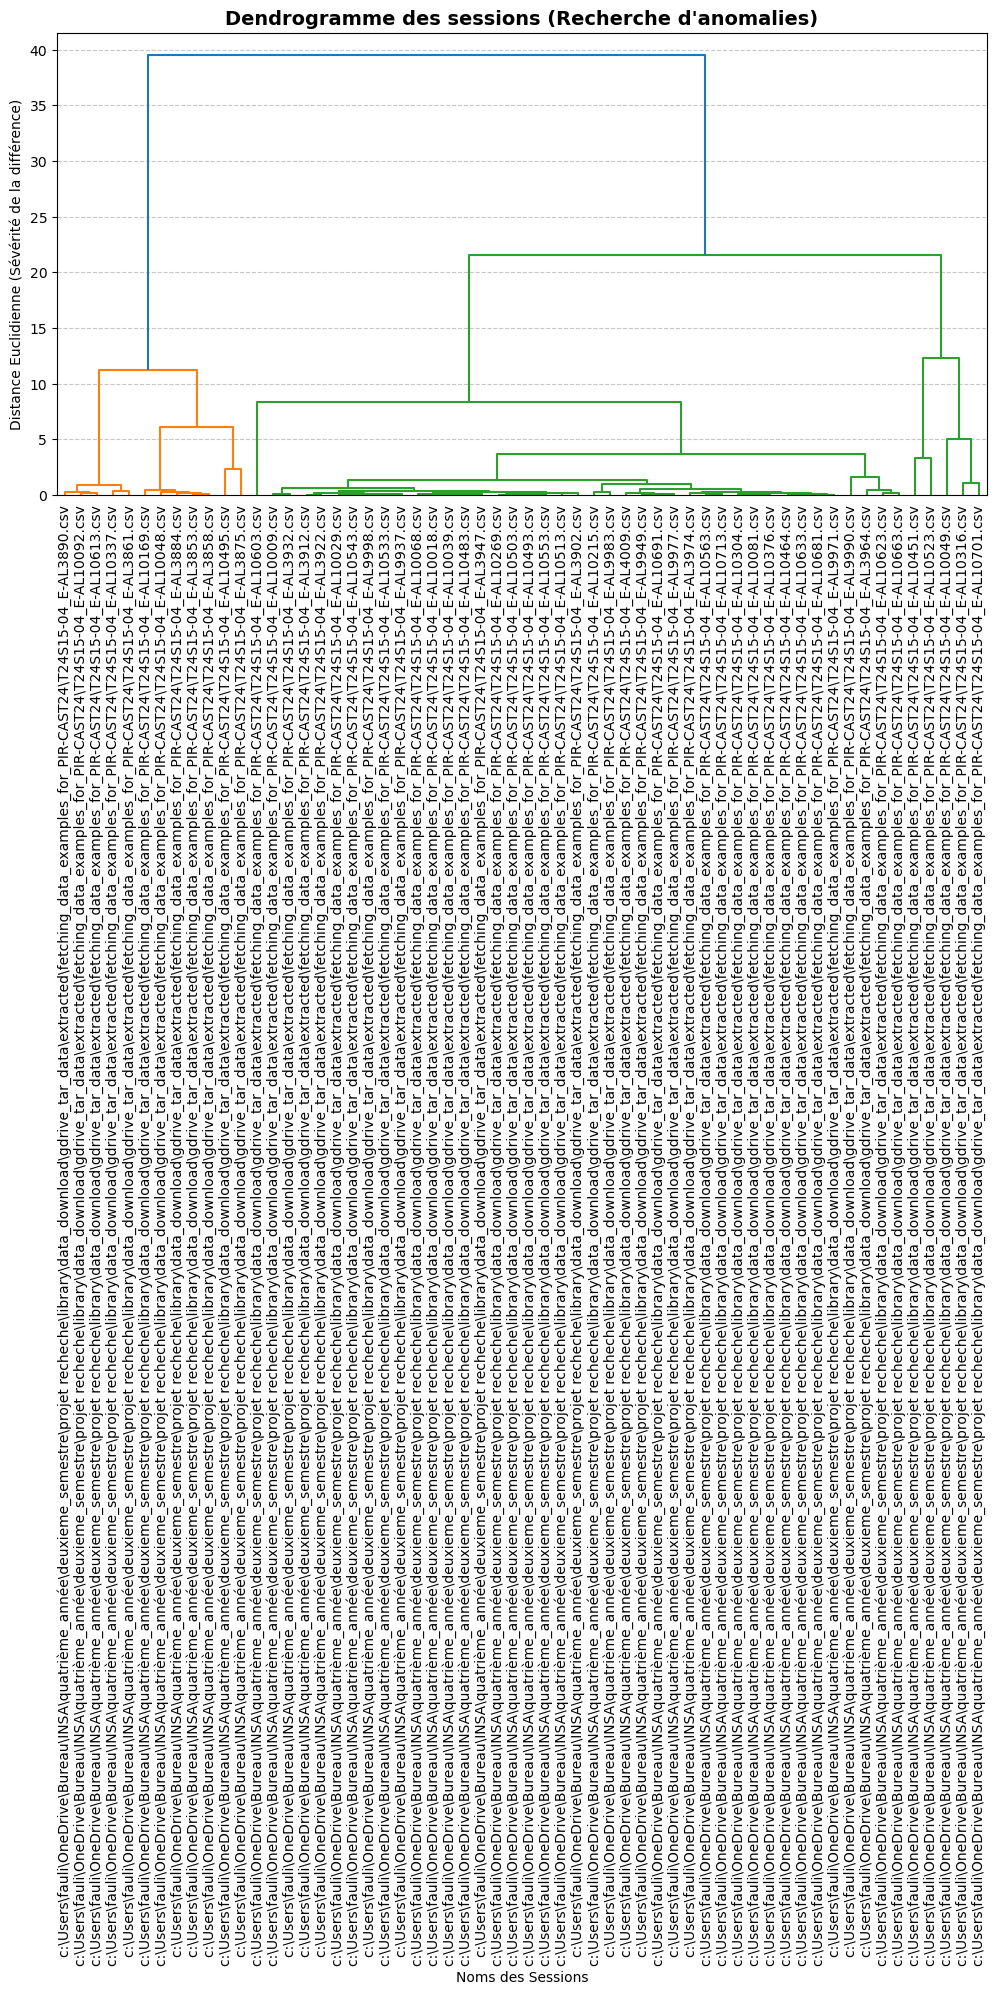

In [19]:
plt.figure(figsize=(12, 6))
# On dessine l'arbre
sch.dendrogram(cah, labels=session_names, leaf_rotation=90, leaf_font_size=10)
plt.title("Dendrogramme des sessions (Recherche d'anomalies)", fontsize=14, fontweight='bold')
plt.ylabel("Distance Euclidienne (Sévérité de la différence)")
plt.xlabel("Noms des Sessions")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

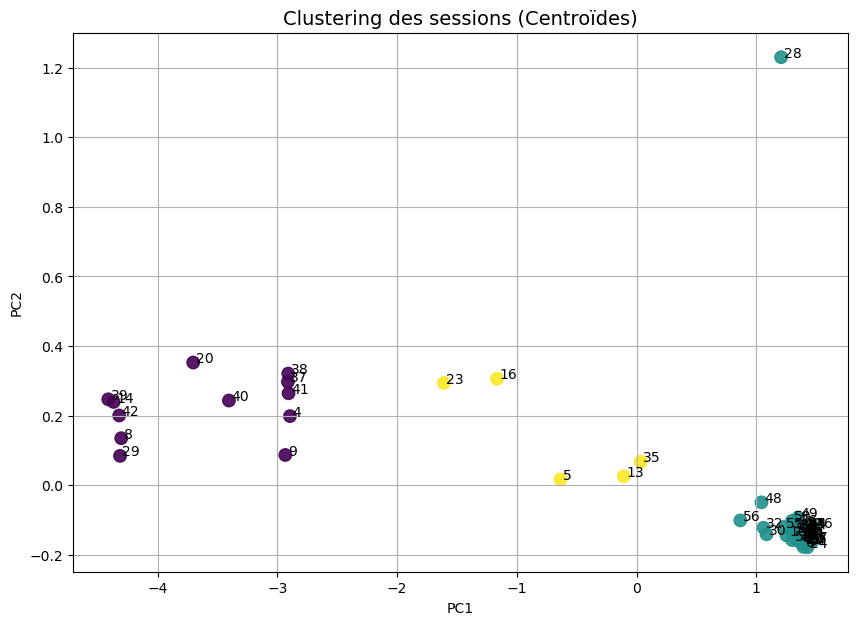

Cluster 2 contient 41 sessions.
Cluster 1 contient 12 sessions.
Cluster 3 contient 5 sessions.


In [26]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# --- 1. DÉCOUPAGE EN 2 CLUSTERS ---
k = 3
# On récupère les identifiants de cluster (1 ou 2) pour chaque session
labels_pca = sch.fcluster(cah, t=k, criterion="maxclust") 

# On assigne ce cluster à notre tableau de centroïdes
centroid_pca["cluster"] = labels_pca

# Pour vérifier qui est dans quel cluster (comme le code de ton camarade)
clusters_pca = {}
for s, c in zip(session_names, labels_pca):
    clusters_pca.setdefault(c, []).append(s)

# --- 2. AFFICHAGE STYLE "CAMARADE" ---
plt.figure(figsize=(10, 7))

# Le paramètre cmap='viridis' est celui qui donne ces couleurs jaune/violet classiques
plt.scatter(centroid_pca["PC1"], centroid_pca["PC2"], 
            c=centroid_pca["cluster"], cmap='viridis', s=80, alpha=0.9)

# On boucle pour afficher le NUMÉRO (i) à côté de chaque point
for i, (idx, row) in enumerate(centroid_pca.iterrows()):
    # On décale très légèrement le texte (+0.02) pour ne pas l'écrire pile sur le point
    plt.text(row["PC1"] + 0.02, row["PC2"], str(i), fontsize=10)

plt.grid(True)
plt.title("Clustering des sessions (Centroïdes)", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# On affiche rapidement le contenu des clusters pour t'aider à trier
for cluster_id, sessions in clusters_pca.items():
    print(f"Cluster {cluster_id} contient {len(sessions)} sessions.")

**Conclusion**: le cluster 2 correspond au session normale

In [33]:

sessions_valides2 = [s for s, c in zip(session_names, labels_pca) if c == 2]

print(f"✅ Nombre de sessions saines récupérées : {len(sessions_valides2)}")


print(sessions_valides2)

✅ Nombre de sessions saines récupérées : 41
['c:\\Users\\fauli\\OneDrive\\Bureau\\INSA\\quatrième_année\\deuxieme_semestre\\projet recheche\\library\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-CAST24\\T24S15-04_E-AL10009.csv', 'c:\\Users\\fauli\\OneDrive\\Bureau\\INSA\\quatrième_année\\deuxieme_semestre\\projet recheche\\library\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-CAST24\\T24S15-04_E-AL10018.csv', 'c:\\Users\\fauli\\OneDrive\\Bureau\\INSA\\quatrième_année\\deuxieme_semestre\\projet recheche\\library\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-CAST24\\T24S15-04_E-AL10029.csv', 'c:\\Users\\fauli\\OneDrive\\Bureau\\INSA\\quatrième_année\\deuxieme_semestre\\projet recheche\\library\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-CAST24\\T24S15-04_E-AL10039.csv', 'c:\\Users\\fauli\\OneDrive\\Bureau\\INSA\\quatrième_année\\deuxieme_semestre\\projet recheche\\library

# Recupérations des sessions saines

In [36]:
import joblib

# Sauvegarde de la liste sur ton disque/Drive
joblib.dump(sessions_valides2, 'models/sessions_saines_circuit2.joblib')


['models/sessions_saines_circuit2.joblib']